In [4]:
!pip -q install faiss-cpu

In [37]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from transformers import (
    CLIPProcessor,
    CLIPModel,
    BlipProcessor,
    BlipForConditionalGeneration
)

In [39]:
# Load Fashion Product Dataset
dataset_path="/kaggle/input/datasets/yanalajyotishreddy/fashion-product-images-small/myntradataset"

image_folder=dataset_path+"/images"

styles_path=dataset_path+"/styles.csv"

In [40]:
styles=pd.read_csv(styles_path,on_bad_lines="skip")

styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [41]:
image_paths=[]

for img in os.listdir(image_folder):
    if img.endswith(".jpg"):
        image_paths.append(os.path.join(image_folder,img))

print("Total Images :",len(image_paths))

Total Images : 44441


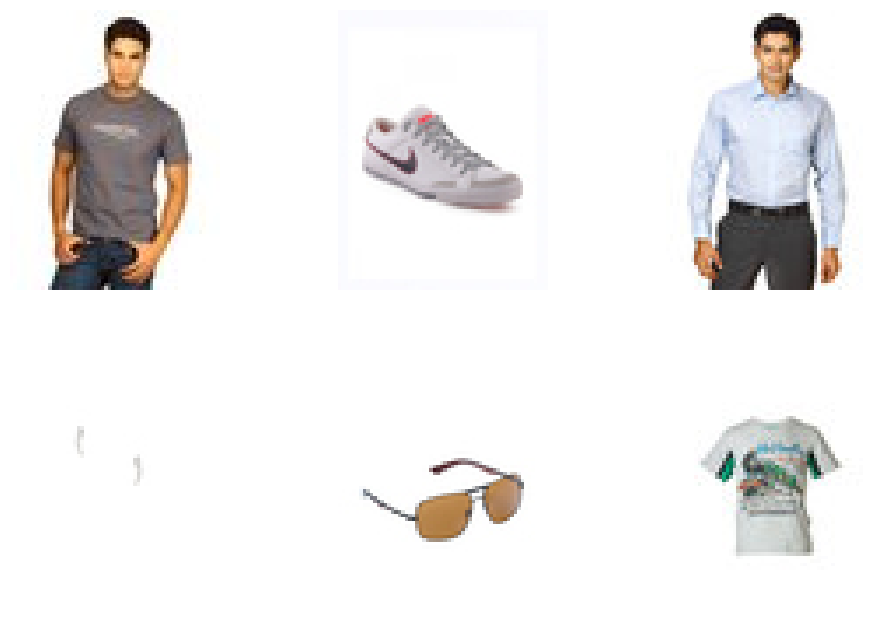

In [42]:
# Visualizing Sample Images

sample=random.sample(image_paths,6)

plt.figure(figsize=(12,8))

for i,path in enumerate(sample):

    plt.subplot(2,3,i+1)

    img=Image.open(path)

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [43]:
# BLIP Image Captioning Model


blip_processor=BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model=BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

print("BLIP Loaded")

BLIP Loaded


In [45]:
def generate_caption(image):

    inputs=blip_processor(images=image,return_tensors="pt")

    output=blip_model.generate(**inputs)

    caption=blip_processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption

In [46]:
sample=Image.open(image_paths[0]).convert("RGB")

caption=generate_caption(sample)

print(caption)

nike air pegasus black / blue


In [47]:
# CLIP Image Embeddings

from transformers import CLIPProcessor, CLIPModel

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("✅ CLIP Loaded Successfully")

✅ CLIP Loaded Successfully


In [49]:
NUM_IMAGES = 1000
BATCH_SIZE = 32

paths = image_paths[:NUM_IMAGES]
embeddings = []

for i in tqdm(range(0, len(paths), BATCH_SIZE)):

    batch_paths = paths[i:i+BATCH_SIZE]

    images = [
        Image.open(p).convert("RGB")
        for p in batch_paths
    ]

    inputs = clip_processor(
        images=images,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        features = clip_model.get_image_features(
            pixel_values=inputs["pixel_values"]
        )

    features = features / features.norm(dim=-1, keepdim=True)

    embeddings.append(features.cpu().numpy())

embeddings = np.vstack(embeddings)

print("Embedding Shape:", embeddings.shape)

100%|██████████| 32/32 [01:28<00:00,  2.76s/it]

Embedding Shape: (1000, 512)


In [50]:
#FAISS Vector Database

import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings.astype("float32"))

print("Indexed Images:", index.ntotal)

Indexed Images: 1000


In [51]:
# Image Similarity Search

import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings.astype("float32"))

print("Indexed Images:", index.ntotal)

Indexed Images: 1000


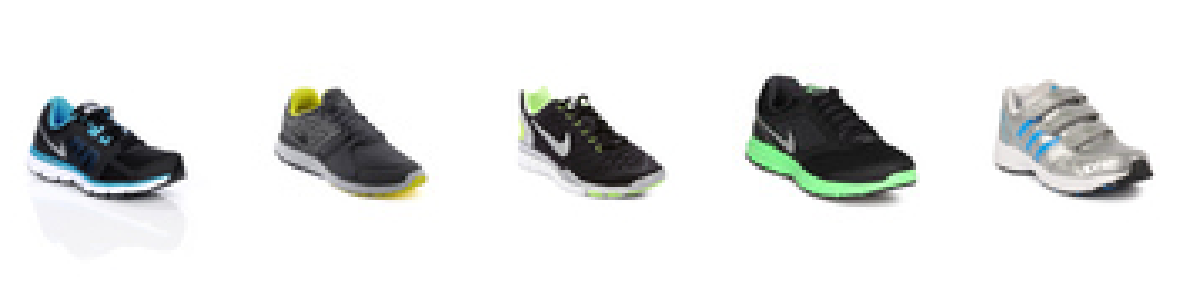

In [52]:
#Test Similarity Search

results = search_similar(0)

plt.figure(figsize=(15,4))

for i, idx in enumerate(results):

    plt.subplot(1,5,i+1)

    img = Image.open(paths[idx])

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [61]:
# Task 1: Smart Product Recommendation Engine

recommendation_rules = {

    "Shoes": [
        "Sports Socks",
        "Fitness Watch",
        "Water Bottle",
        "Gym Bag"
    ],

    "Sports Shoes": [
        "Sports Socks",
        "Fitness Watch",
        "Water Bottle",
        "Gym Bag"
    ],

    "Casual Shoes": [
        "Backpack",
        "Sunglasses",
        "Cap"
    ],

    "Shirts": [
        "Jeans",
        "Belt",
        "Watch",
        "Sneakers"
    ],

    "Tshirts": [
        "Jeans",
        "Sneakers",
        "Cap",
        "Backpack"
    ],

    "Jeans": [
        "Shirt",
        "Sneakers",
        "Belt"
    ],

    "Dress": [
        "Handbag",
        "Heels",
        "Necklace"
    ],

    "Kurta": [
        "Leggings",
        "Sandals",
        "Dupatta"
    ],

    "Sandals": [
        "Handbag",
        "Sunglasses"
    ]
}

In [62]:
metadata = {}

for _, row in styles.iterrows():

    metadata[str(row["id"])] = {

        "name": row["productDisplayName"],

        "articleType": row["articleType"],

        "category": row["masterCategory"],

        "subCategory": row["subCategory"],

        "colour": row["baseColour"]

    }

print("Metadata Loaded :", len(metadata))

Metadata Loaded : 44424


In [64]:
sample = styles.sample(1).iloc[0]

product_name = sample["productDisplayName"]

article_type = sample["articleType"]

recommendations = recommend_product(
    product_name,
    article_type
)

Selected Product
John Players Men Grey Striped Shirt

Article Type
Shirts

Recommended Products
• Jeans
• Belt
• Watch
• Sneakers


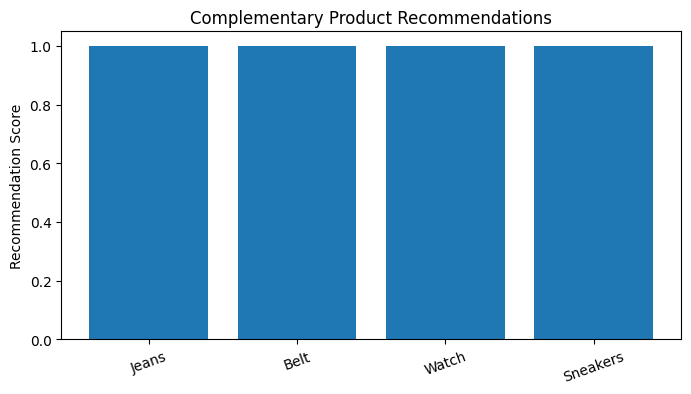

In [65]:
plt.figure(figsize=(8,4))

plt.bar(

    recommendations,

    [1]*len(recommendations)

)

plt.title("Complementary Product Recommendations")

plt.ylabel("Recommendation Score")

plt.xticks(rotation=20)

plt.show()

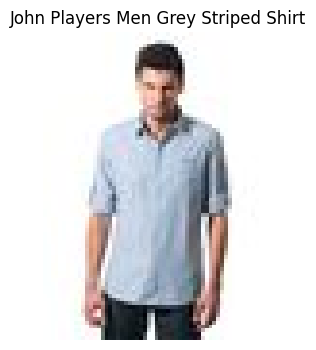

In [66]:
product_id = str(sample["id"])

image_path = os.path.join(
    image_folder,
    product_id + ".jpg"
)

if os.path.exists(image_path):

    plt.figure(figsize=(4,4))

    plt.imshow(Image.open(image_path))

    plt.title(product_name)

    plt.axis("off")

    plt.show()

else:

    print("Image not found")

In [67]:
print("Product Information")

print("-"*50)

print("Name :", product_name)

print("Category :", sample["masterCategory"])

print("Sub Category :", sample["subCategory"])

print("Article Type :", article_type)

print("Colour :", sample["baseColour"])

print()

print("Frequently Bought Together")

for i, item in enumerate(recommendations, 1):

    print(f"{i}. {item}")

Product Information
--------------------------------------------------
Name : John Players Men Grey Striped Shirt
Category : Apparel
Sub Category : Topwear
Article Type : Shirts
Colour : Grey

Frequently Bought Together
1. Jeans
2. Belt
3. Watch
4. Sneakers


In [68]:
# Task 2 – Unique Product Catalog Creation
from sklearn.metrics.pairwise import cosine_similarity

In [69]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix Shape :", similarity_matrix.shape)

Similarity Matrix Shape : (1000, 1000)


In [70]:
THRESHOLD = 0.95

duplicate_pairs = []

for i in range(len(similarity_matrix)):
    for j in range(i + 1, len(similarity_matrix)):

        if similarity_matrix[i][j] > THRESHOLD:

            duplicate_pairs.append({
                "Image1": i,
                "Image2": j,
                "Similarity": similarity_matrix[i][j]
            })

print("Duplicate Products Found :", len(duplicate_pairs))

Duplicate Products Found : 362


In [71]:
duplicates_df = pd.DataFrame(duplicate_pairs)

duplicates_df.head()

,Image1,Image2,Similarity
0,6,758,0.952168
1,13,578,0.956692
2,21,148,0.957560
3,21,742,0.970228
4,21,796,0.956305


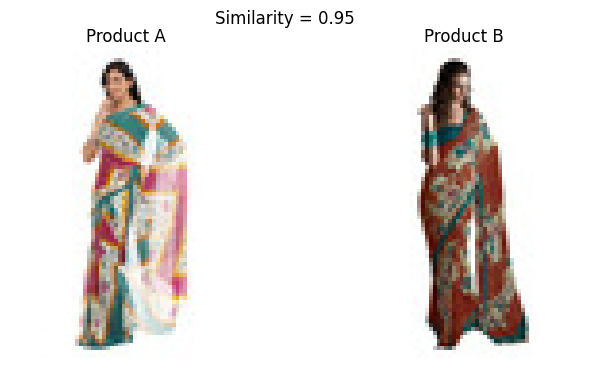

In [72]:
if len(duplicate_pairs) > 0:

    first = duplicate_pairs[0]

    img1 = paths[first["Image1"]]
    img2 = paths[first["Image2"]]

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(Image.open(img1))
    plt.title("Product A")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(Image.open(img2))
    plt.title("Product B")
    plt.axis("off")

    plt.suptitle(
        f'Similarity = {first["Similarity"]:.2f}'
    )

    plt.show()

else:

    print("No duplicate products found.")

In [73]:
visited = set()

unique_catalog = []

for i in range(len(paths)):

    if i in visited:
        continue

    unique_catalog.append(i)

    visited.add(i)

    for j in range(i + 1, len(paths)):

        if similarity_matrix[i][j] > THRESHOLD:

            visited.add(j)

print("Original Products :", len(paths))

print("Unique Products :", len(unique_catalog))

Original Products : 1000
Unique Products : 857


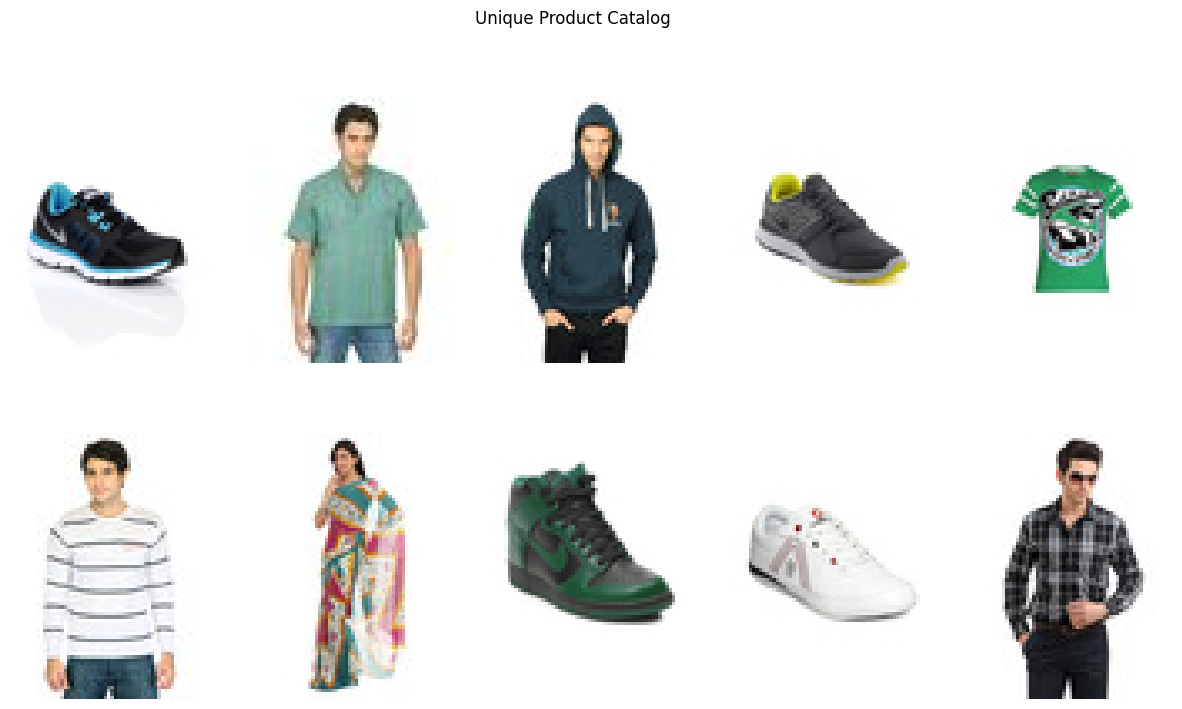

In [74]:
plt.figure(figsize=(15,8))

for i, idx in enumerate(unique_catalog[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(Image.open(paths[idx]))

    plt.axis("off")

plt.suptitle("Unique Product Catalog")

plt.show()

In [75]:
catalog = pd.DataFrame({

    "Image Path":[paths[i] for i in unique_catalog]

})

catalog.head()

,Image Path
0,/kaggle/input/datasets/yanalajyotishreddy/fash...
1,/kaggle/input/datasets/yanalajyotishreddy/fash...
2,/kaggle/input/datasets/yanalajyotishreddy/fash...
3,/kaggle/input/datasets/yanalajyotishreddy/fash...
4,/kaggle/input/datasets/yanalajyotishreddy/fash...


In [76]:
catalog.to_csv(
    "unique_product_catalog.csv",
    index=False
)

print("Unique Product Catalog Saved Successfully!")

Unique Product Catalog Saved Successfully!


In [77]:
# Task 3: Reverse Product Search

def text_embedding(text):

    inputs = clip_processor(
        text=[text],
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)

    features = features / features.norm(dim=-1, keepdim=True)

    return features.cpu().numpy().astype("float32")

In [78]:
def reverse_product_search(query, top_k=5):

    query_embedding = text_embedding(query)

    scores, indices = index.search(query_embedding, top_k)

    return scores[0], indices[0]

In [79]:
query = "blue casual shirt"

scores, results = reverse_product_search(query)

print("Query :", query)

print()

print("Top Matching Products")

for i, idx in enumerate(results):

    print(f"{i+1}. Image Index : {idx}")

Query : blue casual shirt

Top Matching Products
1. Image Index : 859
2. Image Index : 17
3. Image Index : 118
4. Image Index : 325
5. Image Index : 653


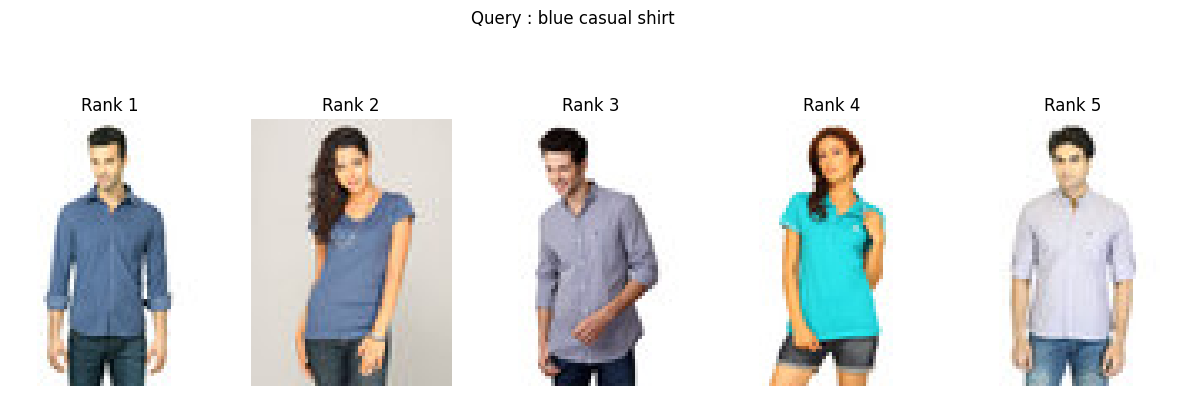

In [80]:
plt.figure(figsize=(15,5))

for i, idx in enumerate(results):

    plt.subplot(1,5,i+1)

    image = Image.open(paths[idx])

    plt.imshow(image)

    plt.axis("off")

    plt.title(f"Rank {i+1}")

plt.suptitle(f"Query : {query}")

plt.show()

In [81]:
result_df = pd.DataFrame({

    "Rank": range(1, len(results)+1),

    "Image Index": results,

    "Similarity Score": scores

})

result_df

,Rank,Image Index,Similarity Score
0,1,859,0.290784
1,2,17,0.285131
2,3,118,0.281136
3,4,325,0.278464
4,5,653,0.277822


Enter Product Description :  blue shirt


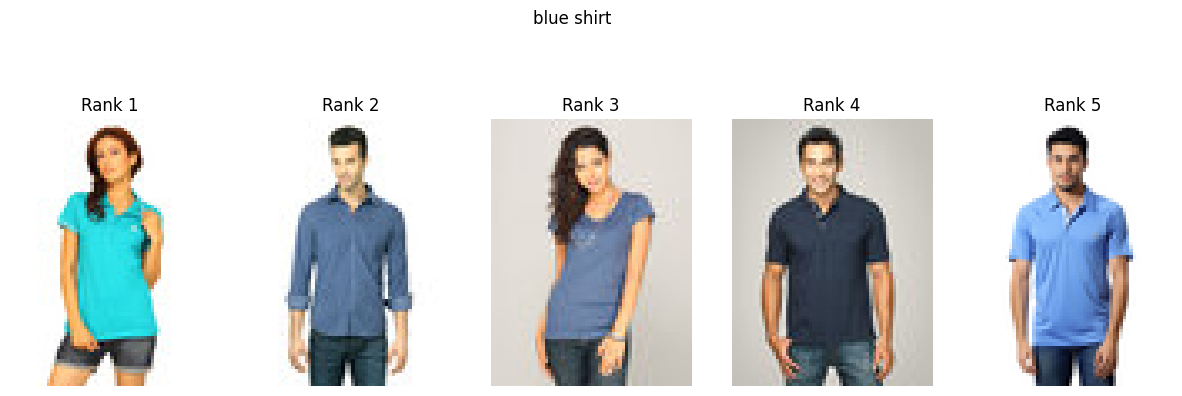

In [82]:
query = input("Enter Product Description : ")

scores, results = reverse_product_search(query)

plt.figure(figsize=(15,5))

for i, idx in enumerate(results):

    plt.subplot(1,5,i+1)

    plt.imshow(Image.open(paths[idx]))

    plt.axis("off")

    plt.title(f"Rank {i+1}")

plt.suptitle(query)

plt.show()

In [83]:
for idx in results:

    image_name = os.path.basename(paths[idx]).replace(".jpg", "")

    row = styles[styles["id"].astype(str) == image_name]

    if len(row):

        print("Product :", row.iloc[0]["productDisplayName"])

        print("Category :", row.iloc[0]["articleType"])

        print("-"*40)

Product : ADIDAS Women's Blue Polo T-shirt
Category : Tshirts
----------------------------------------
Product : U.S. Polo Assn. Men Solid Blue Shirt
Category : Shirts
----------------------------------------
Product : UCB Women's Basic Neck Navy T-shirt
Category : Tshirts
----------------------------------------
Product : Proline Men Navy Polo T-shirt
Category : Tshirts
----------------------------------------
Product : ADIDAS Men Blue PoloT-Shirt
Category : Tshirts
----------------------------------------
